# High-Resolution Image Synthesis with Latent Diffusion Models (LDMs)

In this tutorial, we will implement and train a **conditional** [Latent Diffusion Model (LDM)](https://arxiv.org/abs/2112.10752) for high-resolution image synthesis using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) library, which is built on top of [PyTorch](https://pytorch.org/). Note that this tutorial will not train a model in real time; instead, it will demonstrate the process of training an LDM using the TorchDiff API.

## Table of Contents

- [Data Preparation](#data-preparation)
- [Perceptual Compression with a Variational Autoencoder (VAE)](#perceptual-compression-with-a-variational-autoencoder-vae)
- [Training an LDM Model](#training-an-ldm-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

## Data Preparation

In this tutorial, we will use the [STL-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.STL10.html) dataset from [Torchvision](https://pytorch.org/vision/stable/). The images in this dataset are RGB images with a shape of `(3, 96, 96)`, making them suitable for training a Latent Diffusion Model (LDM) in this tutorial.

In [13]:
# Import all necessary libraries and modules for training a SDE model
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
# Import required classes from the LDM module of TorchDiff
from torchdiff.ldm import AutoencoderLDM, TrainAE, TrainLDM, SampleLDM
# Import required classes from the SDE module of TorchDiff
from torchdiff.sde import HyperParamsSDE, ForwardSDE, ReverseSDE, TrainSDE, SampleSDE
# Import utility functions from the TorchDiff utils module
from torchdiff.utils import TextEncoder, NoisePredictor, Metrics

## Downloading the STL-10 Dataset from Torchvision

In this section, we will download the [STL-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.STL10.html) dataset using the [Torchvision](https://pytorch.org/vision/stable/) library.

In [2]:
transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=transform)

### Using a Subset of the STL-10 Dataset

In this tutorial, we will use a small subset of the STL-10 dataset for training and validation. Specifically, we will select 100 images for training and 10 images for validation to demonstrate the training process for both the Variational Autoencoder (VAE) and Latent Diffusion Model (LDM).

In [3]:
# Use small subset
train_subset = Subset(train_dataset, torch.randperm(len(train_dataset))[:100])
test_subset = Subset(test_dataset, torch.randperm(len(test_dataset))[:20])

# Create data loaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_subset, batch_size=20, shuffle=False)

### Visualizing Training Images

In this section, we will visualize a few images from the training subset.

In [4]:
# STL-10 class names
stl10_classes = ['airplane', 'bird', 'car', 'cat', 'deer', 
                 'dog', 'horse', 'monkey', 'ship', 'truck']

def denormalize(tensor):
    """Convert tensor from [-1, 1] back to [0, 1] for display"""
    return tensor * 0.5 + 0.5

def visualize_stl10_grid(dataloader, num_images=64):
    """
    Visualize STL-10 images in an 8x8 grid with labels
    """
    # Get one batch of images
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    # If batch is smaller than 64, get more batches
    all_images = images
    all_labels = labels
    
    while len(all_images) < num_images:
        try:
            images, labels = next(dataiter)
            all_images = torch.cat([all_images, images])
            all_labels = torch.cat([all_labels, labels])
        except StopIteration:
            # If we run out of data, break
            break
    
    # Take only the first 64 images
    all_images = all_images[:num_images]
    all_labels = all_labels[:num_images]
    
    # Create figure
    fig, axes = plt.subplots(8, 8, figsize=(12, 12))  # Larger figure for 96x96 images
    fig.suptitle('STL-10 Dataset Sample (8x8 Grid)', fontsize=14)
    
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            if idx < len(all_images):
                # Denormalize and convert to numpy
                img = denormalize(all_images[idx])
                img = img.permute(1, 2, 0)  # Change from CHW to HWC
                img = torch.clamp(img, 0, 1)  # Ensure values are in [0, 1]
                
                # Display image
                axes[i, j].imshow(img)
                axes[i, j].set_title(f'{stl10_classes[all_labels[idx]]}', fontsize=10)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

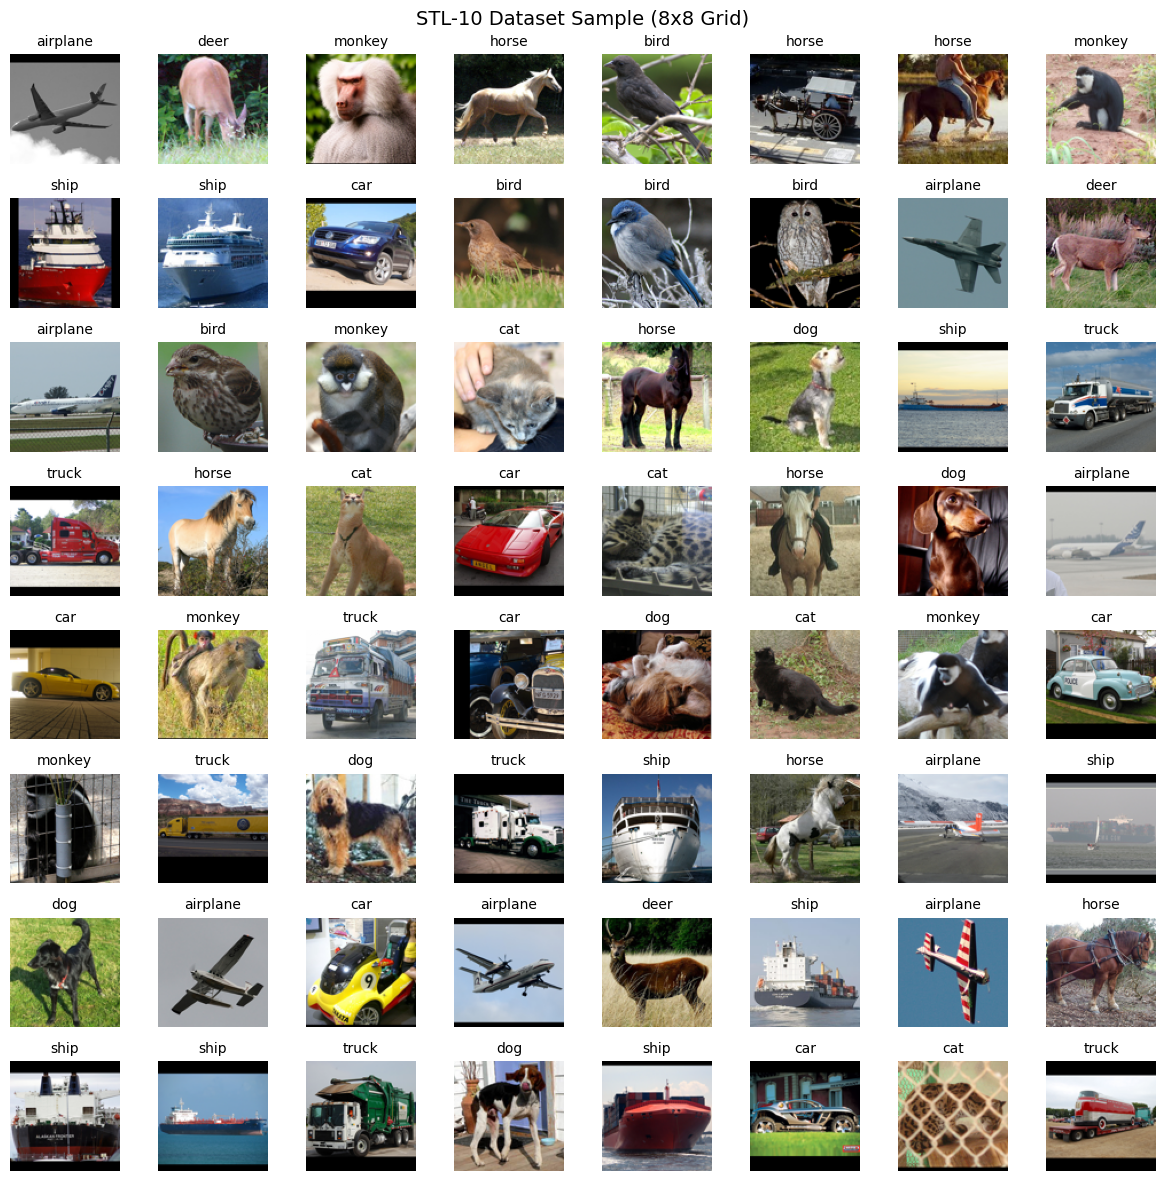

In [5]:
visualize_stl10_grid(train_loader, num_images=64)

### Considerations for Dataset and Scalability

The subset of data which we chose to train is small and not proper to train a diffusion model. However, the focus here is to demonstrate how to use the TorchDiff API. You can scale up the training dataset or switch to more realistic, high-resolution, RGB images based on your specific needs.

## Perceptual Compression with a Variational Autoencoder (VAE)

In this tutorial, we will use the same dataset to train both a compression model and a diffusion model in a compressed latent space. The specific VAE used in TorchDiff is [`torchdiff.ldm.AutoencoderLDM`](https://torchdiff.readthedocs.io/en/latest/ldm.html#torchdiff.ldm.AutoencoderLDM), which encodes images into a latent space and decodes them back to the image space. This VAE serves as the `compressor_model` in [`torchdiff.ldm.TrainLDM`](https://torchdiff.readthedocs.io/en/latest/ldm.html#torchdiff.ldm.TrainLDM) and [`torchdiff.ldm.SampleLDM`](https://torchdiff.readthedocs.io/en/latest/ldm.html#torchdiff.ldm.SampleLDM). In this example, input images with a shape of `(3, 96, 96)` are encoded into a latent space with a shape of `(2, 32, 32)` and then decoded back to the original shape of `(3, 96, 96)`.

In [7]:
# train auto-encoder of ldm models
compressor_model = AutoencoderLDM(
    in_channels=3,
    down_channels=[8, 16],
    up_channels=[16, 8],
    out_channels=3,
    dropout_rate=.1,
    latent_channels=2, # number of channels in latent space
    num_heads=1,
    num_groups=8,
    num_layers_per_block=3,
    total_down_sampling_factor=3,
    num_embeddings=32
)

compressor_metrics = Metrics(device="cpu", fid=True, metrics=True, lpips_=True)

compressor_optimizer = torch.optim.Adam(compressor_model.parameters(), lr=1e-3)
# loss function
obj = nn.MSELoss()

autoencoder_trainer = TrainAE(
    model=compressor_model,
    optimizer=compressor_optimizer,
    data_loader=train_loader,
    val_loader=val_loader,
    max_epoch=5,
    metrics_=compressor_metrics,
    device="cpu",
    save_path="vae_model.pth",
    checkpoint=5,
    kl_warmup_epochs=2,
    patience=5,
    val_frequency=3
)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/loqman/Downloads/projs/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth


In [8]:
# the code below finds out the shape of images in latent space 
x = torch.rand((1, 3, 96, 96))
print("original size: ", x.size())
z, loss = compressor_model.encode(x)
rx = compressor_model.decode(z)
print("latent space shape: ", z.size())
print("reconstracted shape: ", rx.size())

original size:  torch.Size([1, 3, 96, 96])
latent space shape:  torch.Size([1, 2, 32, 32])
reconstracted shape:  torch.Size([1, 3, 96, 96])


In [9]:
train_losses, best_val_loss = autoencoder_trainer()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:35<00:00,  8.79s/it]


Epoch: 1 | Train Loss: 0.4373 | Model saved at epoch 1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:38<00:00,  9.71s/it]


Epoch: 2 | Train Loss: 0.4332 | Model saved at epoch 2


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:43<00:00, 10.80s/it]


...

 | Val Loss: 0.2923 | FID: 377.8916 | MSE: 0.2827 | PSNR: 5.4870 | SSIM: 0.0152 | LPIPS: 0.7531
 | Model saved at epoch 3


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:37<00:00,  9.38s/it]


Epoch: 4 | Train Loss: 0.3430

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:34<00:00,  8.59s/it]

Epoch: 5 | Train Loss: 0.3131

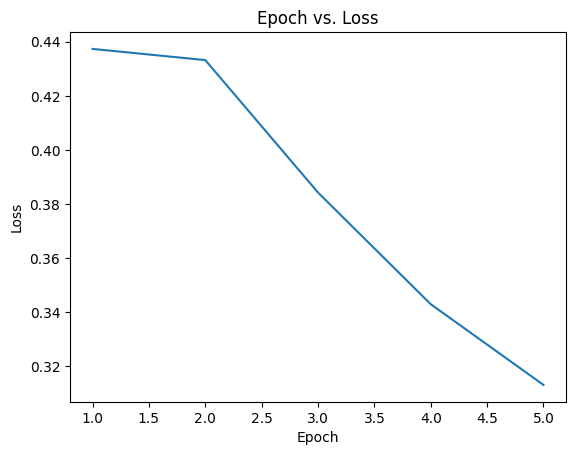

In [10]:
plt.plot([i for i in range(1, 6)], train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

## Training a Latent Diffusion Model (LDM)

After encoding data into the latent space, a diffusion model (e.g., DDPM, DDIM, or SDE) is trained in this latent space. In this tutorial, we use an SDE model as the diffusion model. Before training the SDE in the latent space, we need to prepare several key components required for the training process:

- **Noise Predictor ([`torchdiff.utils.NoisePredictor`](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.NoisePredictor))**:
  This module predicts the noise added to the data and uses this prediction to denoise the data during the backward pass of the diffusion process. For more details, refer to the [TorchDiff NoisePredictor documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.NoisePredictor).

- **Text Encoder ([`torchdiff.utils.TextEncoder`](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.TextEncoder))**:
  A transformer-based encoder for text prompts or image labels in conditional diffusion models. For more details, refer to the [TorchDiff TextEncoder documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.TextEncoder).

- **Optimizer ([`torch.optim.AdamW`](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW))**:
  For training the diffusion model, we use the AdamW optimizer, which is well-suited for optimizing neural networks due to its weight decay regularization.

- **Loss Function ([`torch.nn.MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))**:
  This tutorial uses the Mean Squared Error (MSE) loss from PyTorch to compute the difference between the predicted noise (from the `NoisePredictor`) and the actual noise added during the forward pass.

- **Metrics ([`torchdiff.utils.Metrics`](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.Metrics))**:
  This class from the TorchDiff library computes various evaluation metrics based on the specified requirements. The supported metrics include:
  - Fréchet Inception Distance (FID) (if `fid=True`).
  - Learned Perceptual Image Patch Similarity (LPIPS) (if `lpips=True`).
  - Additional metrics: Mean Squared Error (MSE), Peak Signal-to-Noise Ratio (PSNR), and Structural Similarity Index (SSIM) (if `metrics=True`).
  For more details, refer to the [TorchDiff Metrics documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.Metrics).

In [23]:
# Initialize the NoisePredictor for the SDE model with parameters for RGB images
noise_predictor_ldm = NoisePredictor(
    in_channels=2,  # number of latent space channels
    down_channels=[16, 32],
    mid_channels=[32, 32], 
    up_channels=[32, 16],
    down_sampling=[True, True],
    time_embed_dim=32,
    y_embed_dim=32,
    num_down_blocks=2,
    num_mid_blocks=2,
    num_up_blocks=2,
    down_sampling_factor=2
)

# label conditional model
text_encoder_ldm = TextEncoder(
    use_pretrained_model=True,
    model_name="bert-base-uncased",
    vocabulary_size=30522,
    num_layers=2,
    input_dimension=32,
    output_dimension=32,
    num_heads=2,
    context_length=77
)

# Set up the AdamW optimizer for the NoisePredictor parameters plus TextEncoder trainable parameters with a learning rate of 1e-3
optimizer_ldm = torch.optim.Adam(
    [p for p in noise_predictor_ldm.parameters() if p.requires_grad] +
    [p for p in text_encoder_ldm.parameters() if p.requires_grad], lr=1e-5
)

# Initialize the Mean Squared Error (MSE) loss function
loss_ldm = nn.MSELoss()

# Configure the Metrics class for evaluation on CPU (GPUs are recommended for actual training)
metrics_ldm = Metrics(
    device="cpu",  # Using CPU for this tutorial, but GPUs are recommended for training diffusion models
    fid=True, 
    metrics=True, 
    lpips_=True
)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/loqman/Downloads/projs/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth


### Required TorchDiff SDE Classes for Training

To train the SDE model, this tutorial requires the following specific classes from the TorchDiff SDE module:

- **SDE Hyperparameters ([`torchdiff.sde.HyperParamsSDE`](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.HyperParamsSDE))**:
  This class manages the noise schedule for the SDE model, defining parameters for the forward and reverse diffusion processes. For more details, refer to the [TorchDiff HyperParamsSDE documentation](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.HyperParamsSDE).

- **Reverse Diffusion ([`torchdiff.sde.ReverseSDE`](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.ReverseSDE))**:
  This class handles the reverse diffusion process during sampling, enabling the generation of data from noise. For more details, refer to the [TorchDiff ReverseSDE documentation](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.ReverseSDE).

- **SDE Trainer ([`torchdiff.sde.TrainSDE`](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.TrainSDE))**:
  This class manages the training process for the SDE model, integrating the noise predictor, optimizer, and other components. For more details, refer to the [TorchDiff TrainSDE documentation](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.TrainSDE).

In [24]:
# we need to initialize three componets from SDE model (hyperparameter class, forward diffuison class and reverse diffusion class), which will be given to 
# LDM model.

# Initialize SDE hyperparameters for the noise schedule
hyperparams_sde = HyperParamsSDE(
    num_steps=500, 
    beta_start=1e-4, 
    beta_end=0.02,
    sigma_start=1e-3, 
    sigma_end=10.0, 
    start=0.0,
    end=1.0, 
    beta_method="linear"
)

# Set up the reverse diffusion process for sampling
reverse_sde = ReverseSDE(
    hyper_params=hyperparams_sde, 
    method="ode" # there are three stochastic methods and one deterministic method available ("ve", "vp", "sub-vp", "ode"). Here we will use the deterministic (ode) method
)

# forward sde
forward_sde = ForwardSDE(
    hyper_params=hyperparams_sde, 
    method="ode"
)


# Configure the LDM trainer for model training
ldm_trainer = TrainLDM(
    model="sde", # "ddpm", "ddim", "sde"
    forward_model=forward_sde,
    noise_predictor=noise_predictor_ldm,
    hyper_params=hyperparams_sde,
    compressor_model=compressor_model,# trained vae to send images to latent space (encode) and bring them back to original space (decode)
    conditional_model=text_encoder_ldm,
    reverse_diffusion=reverse_sde,
    metrics_=metrics_ldm,
    optimizer=optimizer_ldm,
    objective=loss_ldm,
    data_loader=train_loader,
    val_loader=val_loader,
    max_epoch=10,
    device="cpu",
    store_path="test_ldm.pth",
    val_frequency=5
)

In [25]:
# start trining
train_losses, best_val_loss = ldm_trainer()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:19<00:00,  4.81s/it]


Epoch: 1 | Train Loss: 1.4854


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:19<00:00,  4.95s/it]


Epoch: 2 | Train Loss: 1.4836


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:18<00:00,  4.70s/it]


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:19<00:00,  4.76s/it]


Epoch: 10 | Train Loss: 1.4695Warning: batch size is bigger than the data size. Setting batch size to data size


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.67s/it]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.89s/it]


 | Val Loss: 1.4612 | FID: 399.2759 | MSE: 0.0710 | PSNR: 11.4895 | SSIM: 0.3963 | LPIPS: 0.6889


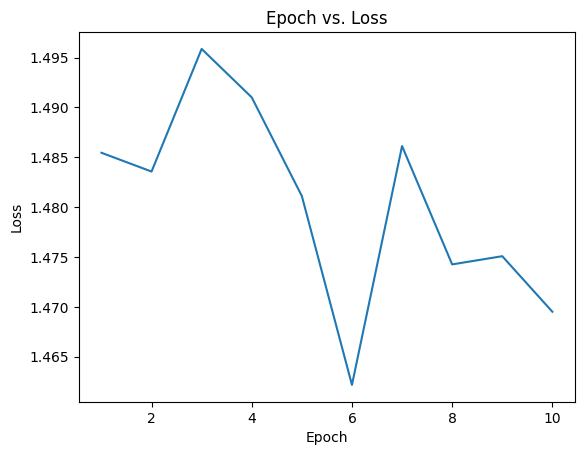

In [26]:
plt.plot([i for i in range(1, 11)], train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

## Sampling from the Latent Diffusion Model (LDM)

After training the Latent Diffusion Model (LDM), we can generate new images. While it is possible to use the trained model directly, it is common to load the trained parameters of the denoising model and generate new data using the [`torchdiff.ldm.SampleLDM`](https://torchdiff.readthedocs.io/en/latest/ldm.html#torchdiff.ldm.SampleLDM) class. In this tutorial, we will load the trained parameters and use them to generate new images.

In [27]:
# Initialize a new NoisePredictor with the same architecture as the trained model
new_noise_predictor = NoisePredictor(
    in_channels=2,  # number of latent space channels
    down_channels=[16, 32],
    mid_channels=[32, 32], 
    up_channels=[32, 16],
    down_sampling=[True, True],
    time_embed_dim=32,
    y_embed_dim=32,
    num_down_blocks=2,
    num_mid_blocks=2,
    num_up_blocks=2,
    down_sampling_factor=2
)

# label conditional model
new_text_encoder = TextEncoder(
    use_pretrained_model=True,
    model_name="bert-base-uncased",
    vocabulary_size=30522,
    num_layers=2,
    input_dimension=32,
    output_dimension=32,
    num_heads=2,
    context_length=77
)

# Initialize SDE hyperparameters for the noise schedule
new_hyperparams_sde = HyperParamsSDE(
    num_steps=500, 
    beta_start=1e-4, 
    beta_end=0.02,
    sigma_start=1e-3, 
    sigma_end=10.0, 
    start=0.0,
    end=1.0, 
    beta_method="linear"
)

# Load the trained model checkpoint from file
checkpoint = torch.load('test_ldm.pth', map_location='cpu')

# Load the trained parameters into the new NoisePredictor and set to evaluation mode
new_noise_predictor.load_state_dict(checkpoint['model_state_dict_noise_predictor'])
new_noise_predictor.eval()
# Print the total number of parameters in the NoisePredictor
print("Number of NoisePredictor's parameters:")
print(sum(p.numel() for p in new_noise_predictor.parameters()))

# Load the trained parameters into the new TextEncoder and set to evaluation mode
new_text_encoder.load_state_dict(checkpoint['model_state_dict_conditional'])
new_text_encoder.eval()
# Print the total  number of parameters in the NoisePredictor
print("Number of TextEncoder's parameters:")
print(sum(p.numel() for p in new_text_encoder.parameters()))



# Load the trained hyperparameters and set to evaluation mode
new_hyperparams_sde.load_state_dict(checkpoint['hyper_params_model'])
new_hyperparams_sde.eval() 
# Print the total number of parameters in the HyperParamsDDPM
print("Number of HyperParamsDDIM's parameters:")
print(sum(p.numel() for p in new_hyperparams_sde.parameters()))

# Set up the reverse diffusion process using the loaded hyperparameters
new_reverse_sde = ReverseSDE(new_hyperparams_sde, "ode")

Number of NoisePredictor's parameters:
159074
Number of TextEncoder's parameters:
109506848
Number of HyperParamsDDIM's parameters:
0


In [28]:
# sampling process
sampler = SampleLDM(
    model="sde",
    reverse_diffusion=new_reverse_sde,
    noise_predictor=new_noise_predictor,
    compressor_model=compressor_model,
    image_shape=(96, 96),
    conditional_model=new_text_encoder,
    tokenizer="bert-base-uncased",
    max_length=77,
    batch_size=10,
    in_channels=3,
    device="cpu",
    output_range=(-1, 1)
)

In [29]:
gen_imgs = sampler(
    conditions=['airplane', 'bird', 'car', 'cat', 'deer', 
                'dog', 'horse', 'monkey', 'ship', 'truck'], # 10 lables as conditions
    save_images=True,
    save_path="ldm_generated"
) # the created images will be stored in the given directory

### Visualizing Generated Images

In this section, we will visualize the images generated by the trained LDM model to inspect the results of the sampling process.

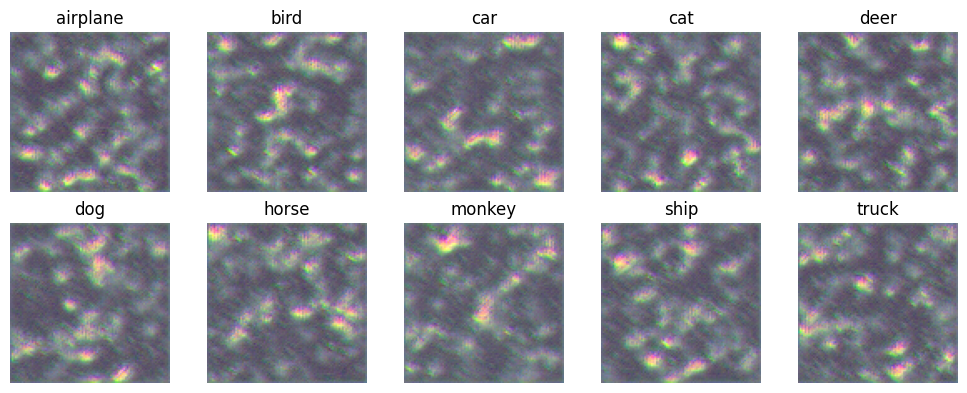

In [30]:
folder_path = "ldm_generated"
conditions=['airplane', 'bird', 'car', 'cat', 'deer', 
                 'dog', 'horse', 'monkey', 'ship', 'truck']
num_images = 10 
rows, cols = 2, 5

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

for i in range(num_images):
    img_path = os.path.join(folder_path, f"image_{i}.png")
    img = Image.open(img_path).convert('RGB') 

    ax = axes[i // cols, i % cols]
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(conditions[i])

plt.tight_layout()
plt.show()

### Evaluating the Generated Images

The generated images may not be of optimal quality, as we trained a shallow Latent Diffusion Model (LDM) and Variational Autoencoder (VAE) for only 10 and 5 epochs, respectively, on a small subset of the STL-10 dataset. This limited training setup is designed to demonstrate the TorchDiff API rather than achieve high-quality results.

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Latent Diffusion Models and Their Implementation in TorchDiff](https://medium.com/@samaniloqman91/latent-diffusion-models-and-their-implementation-in-torchdiff-7dc04c33c4f7)
- [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752)